# Fix Scalers

In [1]:
model = 'lcdm_nu'


## Init

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from emu_like.datasets import Dataset
from emu_like.scalers import Scaler

root = '/ceph/hpc/data/s25r06-05-users'
data_ranges = ['thin', 'std', 'ext']

In [3]:
def print_sign(data):
    y_min = data.min()
    y_max = data.max()
    if np.sign(y_min) == np.sign(y_max):
        if np.sign(y_min) == 1:
            sign = '+'
        else:
            sign = '-'
    else:
        sign = '+/-'
    print('sign {:3}, min {:.2e}, max {:.2e}'.format(sign, y_min, y_max))

    return

In [4]:
def scale_data(data, scaler):
    scal = Scaler.choose_one(scaler)
    scal.fit(data)
    data_scaled = scal.transform(data)
    return data_scaled

In [5]:
def plot_mode_density(
        samples,
        mode_values=None,
        n_bins=100,
        n_levels=30,
        cmap='viridis',
        zero_color='lightgray',
        logy=False,
        logx=False):
    """
    Visualise the per-mode sample density of a 2D array with shape (n_s, n_k).

    Parameters
    ----------
    samples : np.ndarray
        Array of shape (n_s, n_k); each column holds the n_s samples of one mode.
    mode_values : array-like or None
        Optional x-axis ticks for the modes. Defaults to simple indices.
    n_bins : int
        Number of bins used to estimate the 1D density along the sample axis.
    levels : int
        Number of contour levels for plt.contourf.
    cmap : str
        Matplotlib colormap name for the filled contours.
    """
    if samples.ndim != 2:
        raise ValueError('samples must be a 2D array (n_s, n_k)')

    n_s, n_k = samples.shape
    if mode_values is None:
        mode_values = np.arange(n_k)

    y_edges = np.linspace(samples.min(), samples.max(), n_bins + 1)
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    density = np.empty((n_bins, n_k))
    for j in range(n_k):
        hist, _ = np.histogram(samples[:, j], bins=y_edges, density=True)
        density[:, j] = hist

    positive = density[density > 0]
    if positive.size == 0:
        raise ValueError('All densities are zero; adjust binning.')

    min_pos = positive.min()
    max_pos = positive.max()
    levels = np.linspace(min_pos, max_pos, n_levels)

    X, Y = np.meshgrid(mode_values, y_centers)
    if logx:
        X += 1

    fig, ax = plt.subplots(figsize=(10, 6))
    contour = ax.contourf(X, Y, density, levels=levels, cmap=cmap, extend='min')
    contour.cmap.set_under(zero_color)     # color for density == 0
    contour.changed()

    ax.set_xlabel('Mode index' if mode_values is None else 'Mode')
    ax.set_ylabel('Sample value')
    if logy:
        ax.set_yscale('log')
    if logx:
        ax.set_xscale('log')
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Density')
    plt.show()


## Fix Scalers

### pk_m (LogStandardScaler)

In [6]:
spectrum = 'pk_m'
spectrum_type = 'pk'

In [7]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [8]:
# Signs
print_sign(data.y)

sign +  , min 3.22e-04, max 1.70e+01


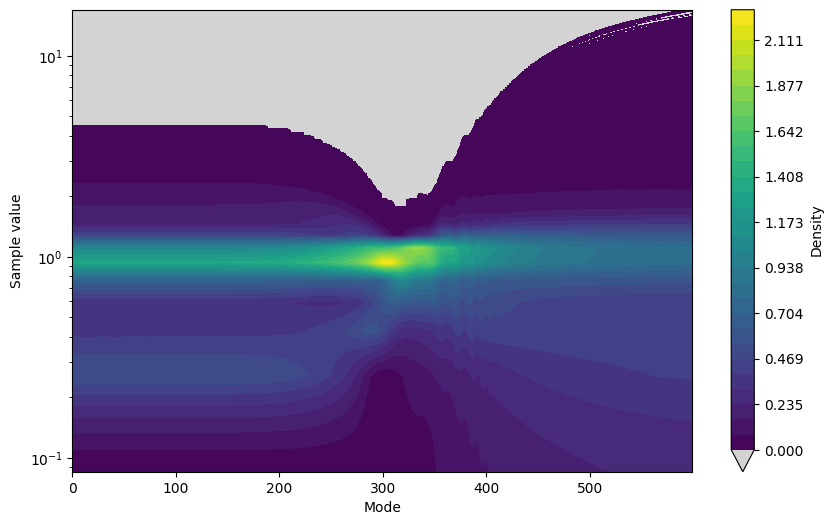

In [9]:
# Raw
plot_mode_density(data.y, logy=True)

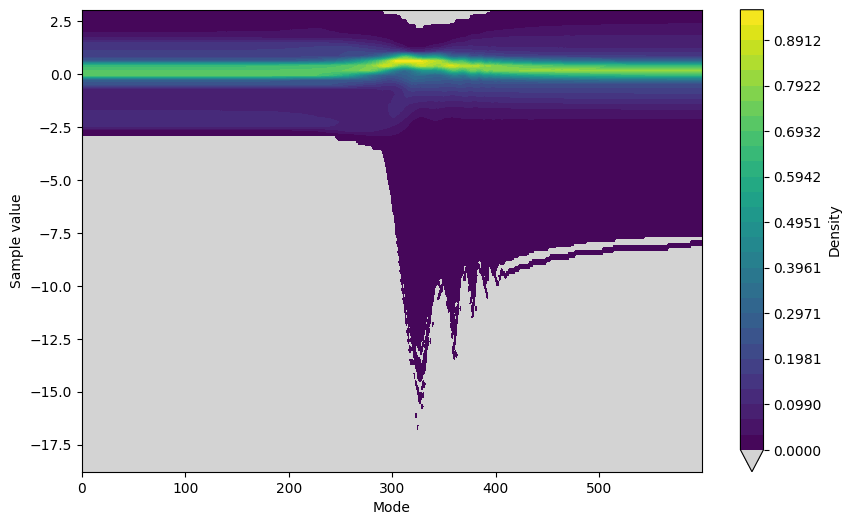

In [10]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

### pk_cb (LogStandardScaler)

In [11]:
spectrum = 'pk_cb'
spectrum_type = 'pk'

In [12]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [13]:
# Signs
print_sign(data.y)

sign +  , min 5.83e-04, max 1.73e+01


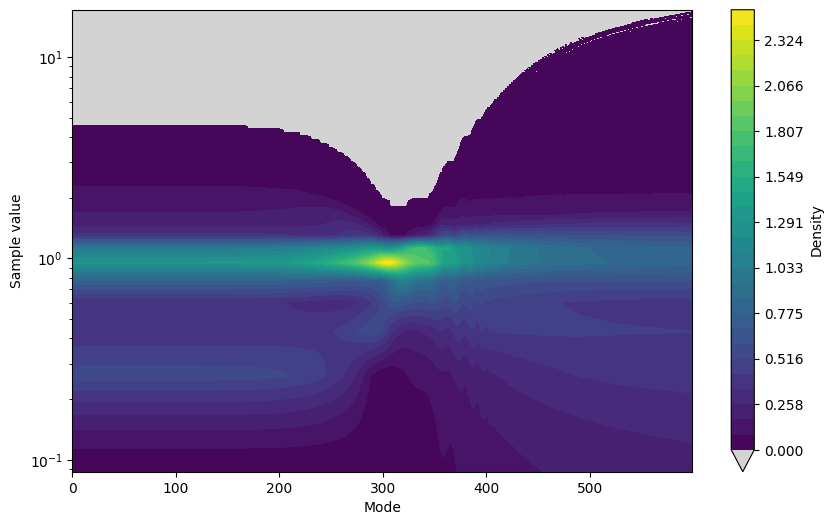

In [14]:
# Raw
plot_mode_density(data.y, logy=True)

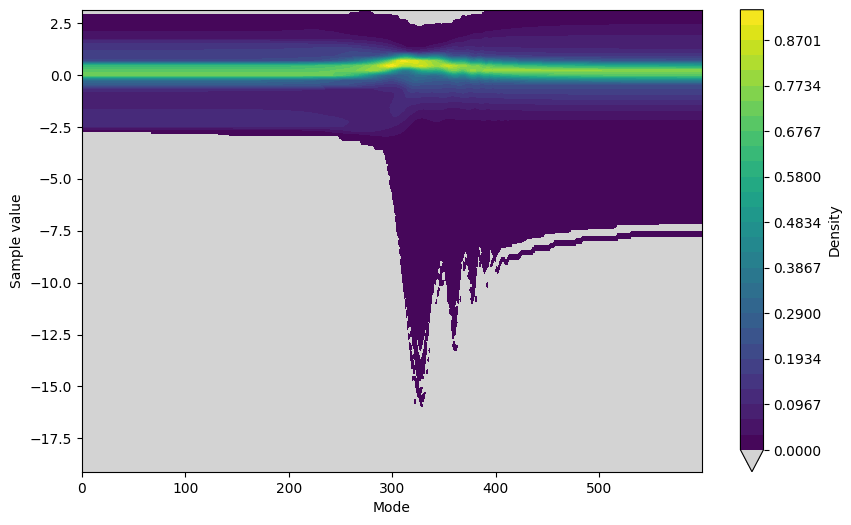

In [15]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

### pk_weyl (LogStandardScaler)

In [16]:
spectrum = 'pk_weyl'
spectrum_type = 'pk'

In [17]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [18]:
# Signs
print_sign(data.y)

sign +  , min 2.28e-05, max 2.46e+02


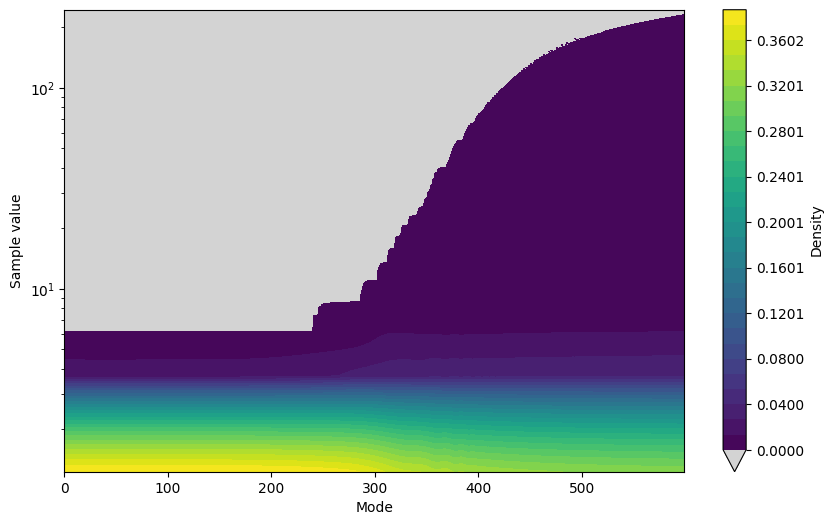

In [19]:
# Raw
plot_mode_density(data.y, logy=True)

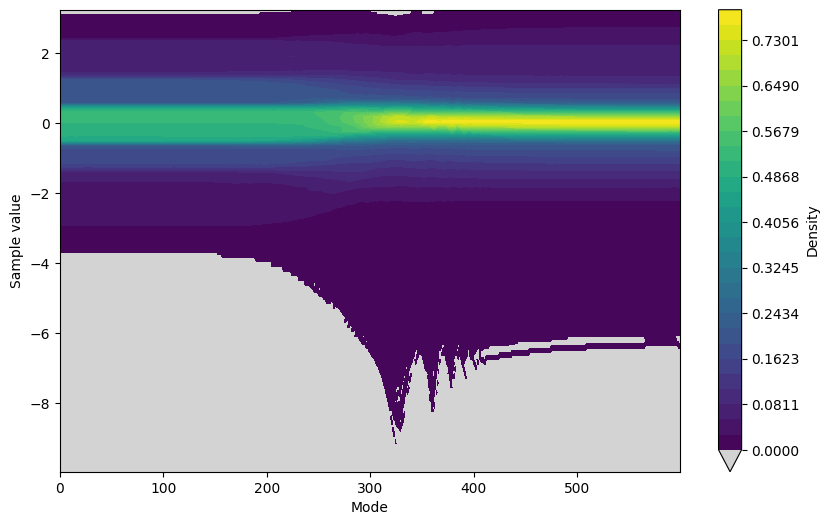

In [20]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

### fk_m (StandardScaler)

In [21]:
spectrum = 'fk_m'
spectrum_type = 'pk'

In [22]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [23]:
# Signs
print_sign(data.y)

sign +  , min 3.15e-01, max 1.01e+00


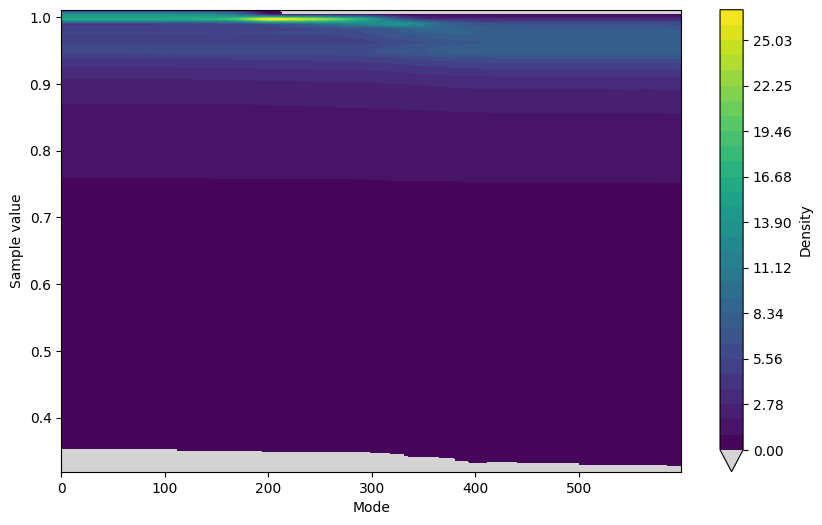

In [24]:
# Raw
plot_mode_density(data.y)

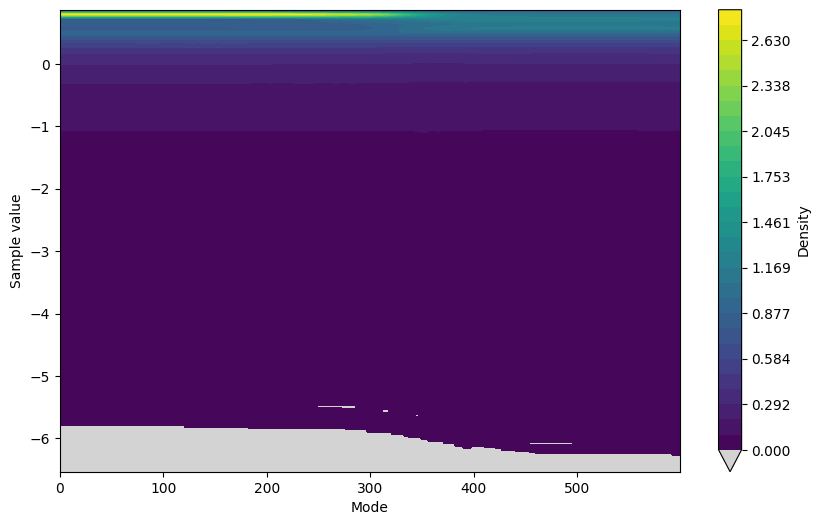

In [25]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

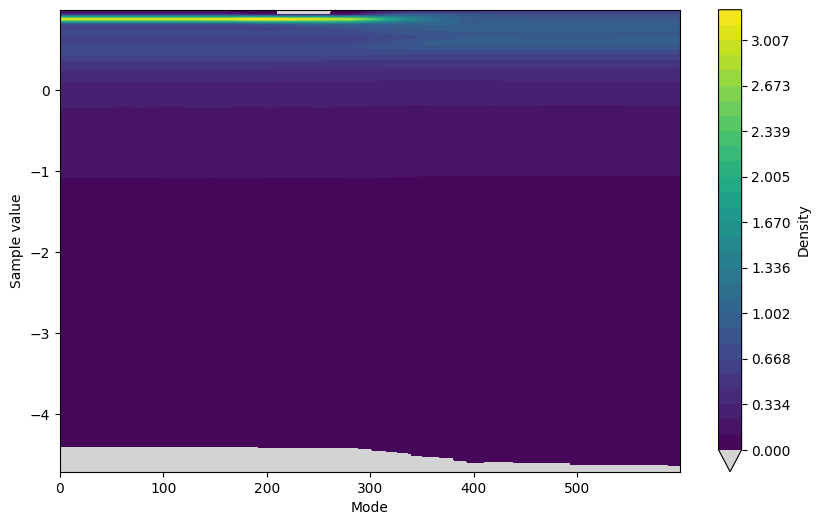

In [26]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

### fk_cb (StandardScaler)

In [27]:
spectrum = 'fk_cb'
spectrum_type = 'pk'

In [28]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [29]:
# Signs
print_sign(data.y)

sign +  , min 3.15e-01, max 1.02e+00


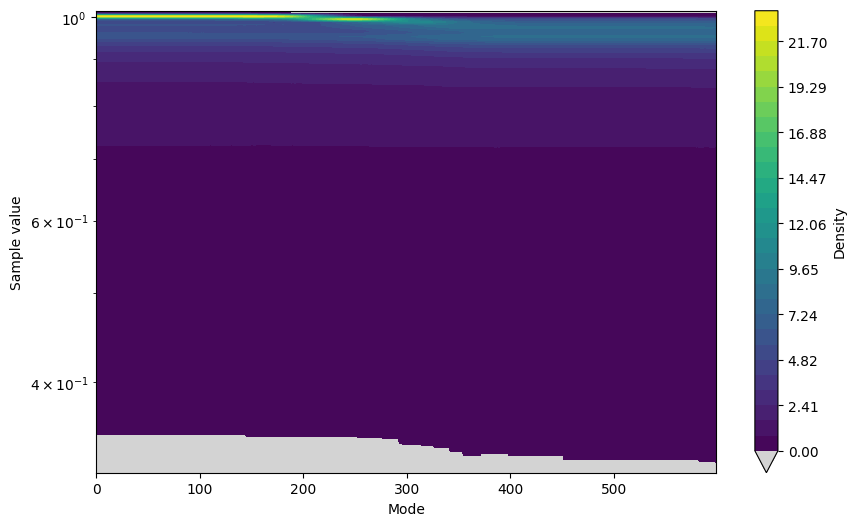

In [30]:
# Raw
plot_mode_density(data.y, logy=True)

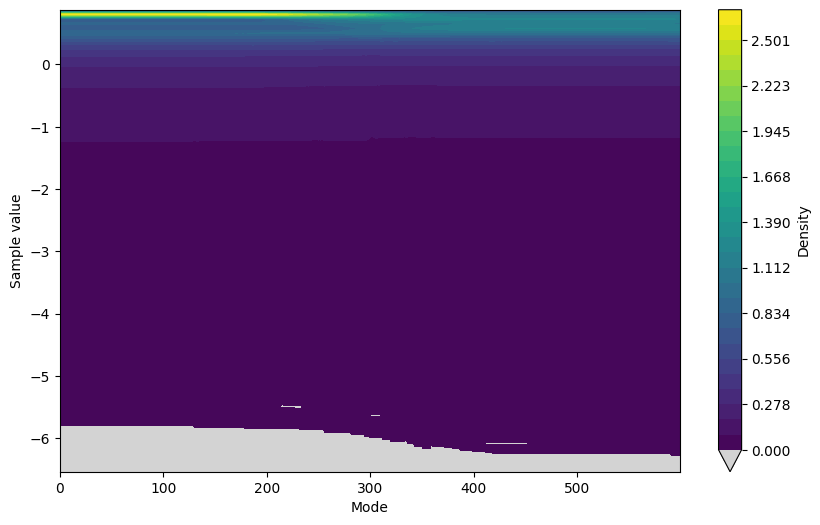

In [31]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

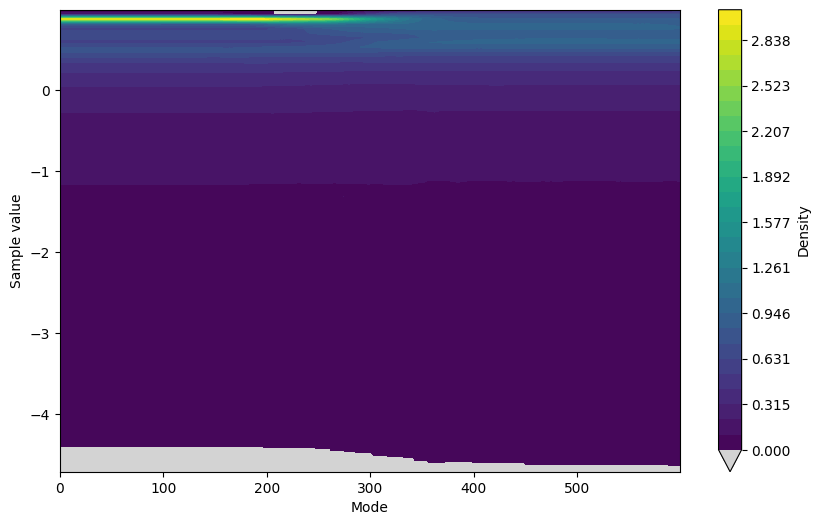

In [32]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

### fk_weyl (minus LogStandardScaler)

In [33]:
spectrum = 'fk_weyl'
spectrum_type = 'pk'

In [34]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [35]:
# Signs
print_sign(data.y)

sign -  , min -6.85e-01, max -4.07e-04


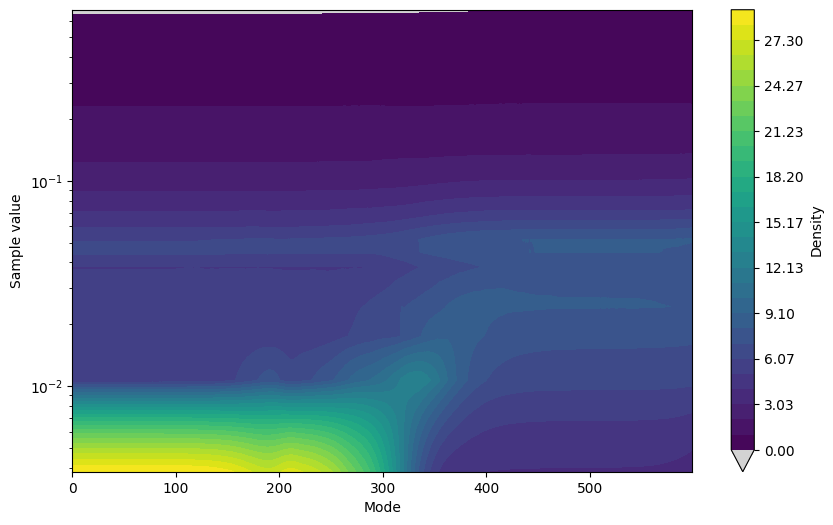

In [36]:
# Raw
plot_mode_density(-data.y, logy=True)

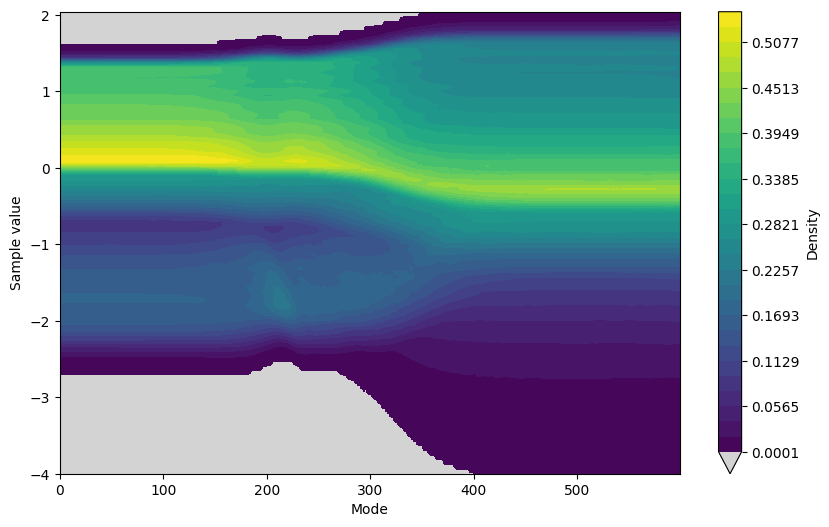

In [37]:
# LogStandardScaler
plot_mode_density(scale_data(-data.y, 'LogStandardScaler'))

### cl_TT_lensed (LogStandardScaler)

In [38]:
spectrum = 'cl_TT_lensed'
spectrum_type = 'cl'

In [39]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [40]:
# Signs
print_sign(data.y)

sign +  , min 3.18e-02, max 1.38e+01


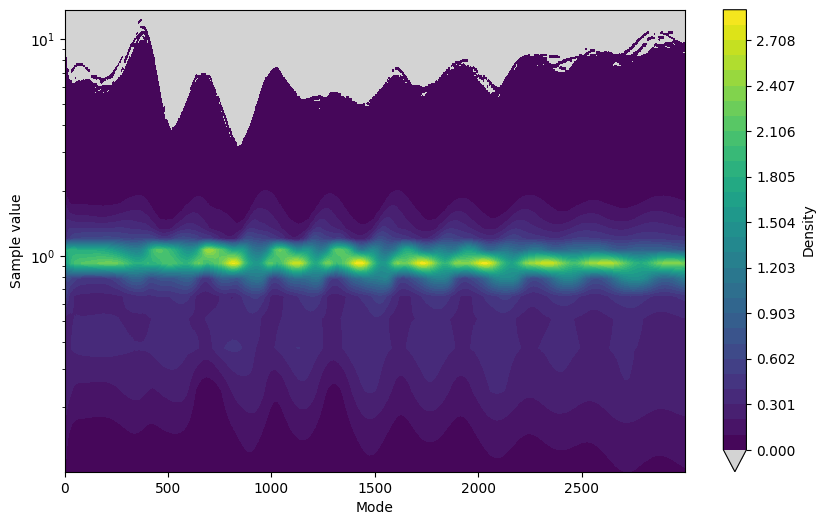

In [41]:
# Raw
plot_mode_density(data.y, logy=True)

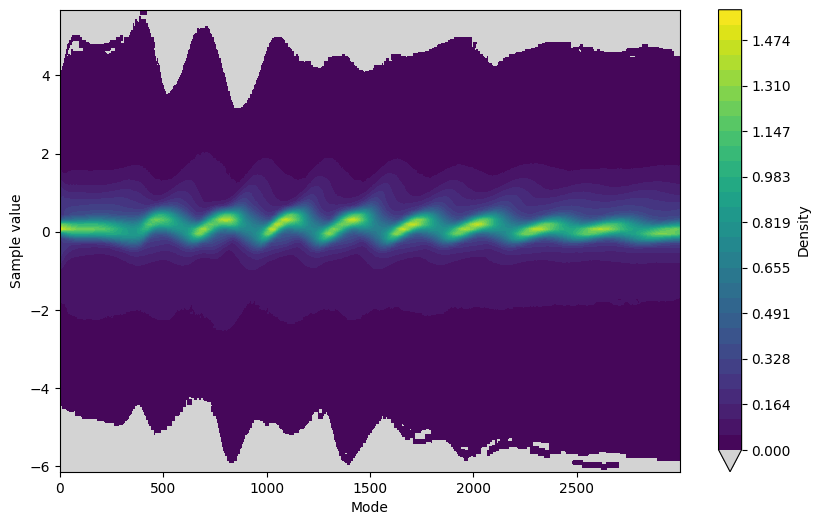

In [42]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

### cl_TE_lensed (StandardScaler)

In [43]:
spectrum = 'cl_TE_lensed'
spectrum_type = 'cl'

In [44]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [45]:
# Signs
print_sign(data.y)

sign +/-, min -8.45e-11, max 1.19e-10


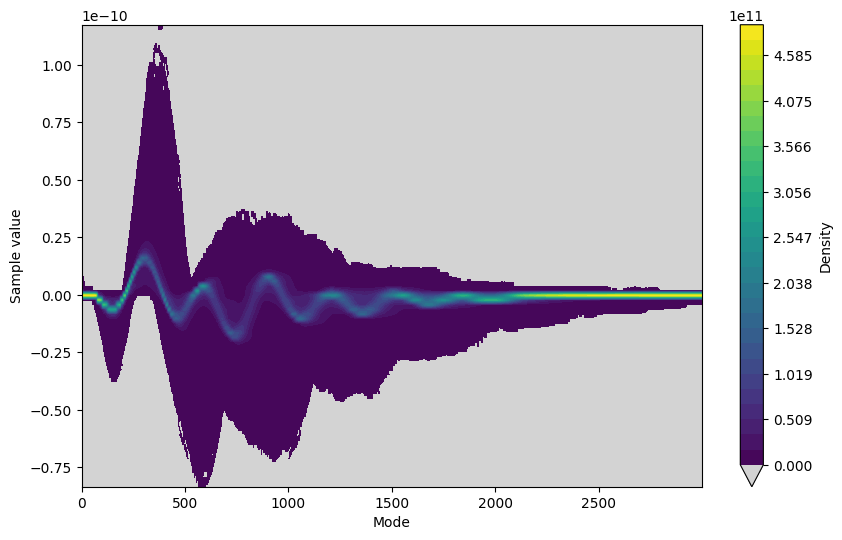

In [46]:
# Raw
plot_mode_density(data.y)

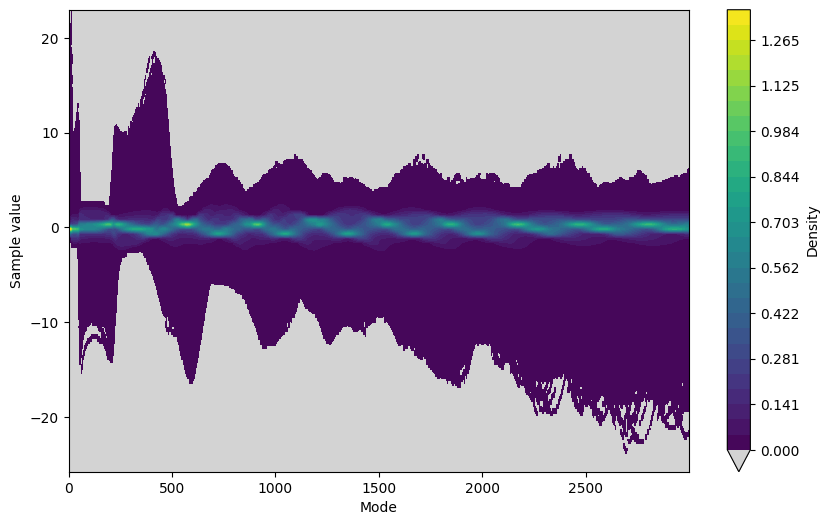

In [47]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

### cl_EE_lensed (LogStandardScaler)

In [48]:
spectrum = 'cl_EE_lensed'
spectrum_type = 'cl'

In [49]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [50]:
# Signs
print_sign(data.y)

sign +  , min 8.22e-04, max 8.86e+02


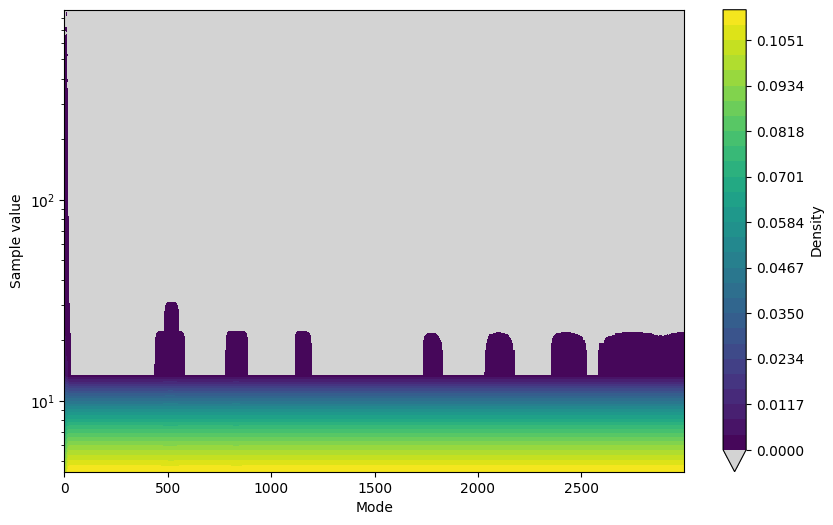

In [51]:
# Raw
plot_mode_density(data.y, logy=True)

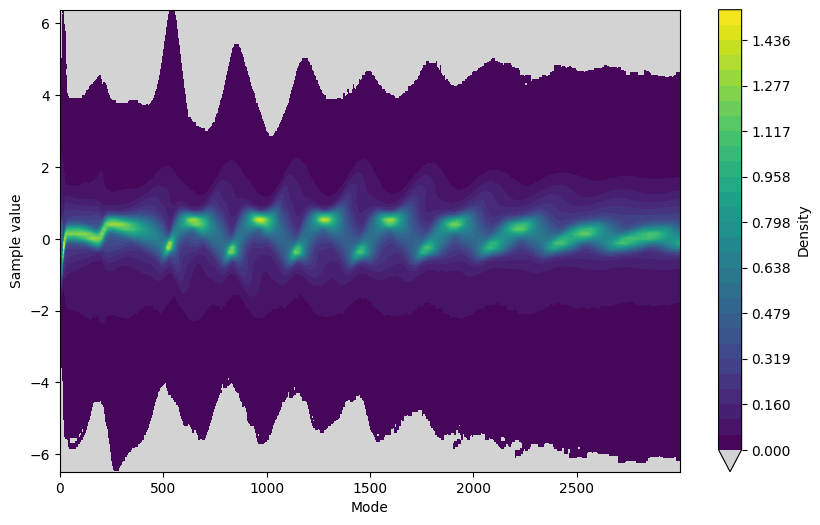

In [52]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

### cl_BB_lensed (LogStandardScaler)

In [53]:
spectrum = 'cl_BB_lensed'
spectrum_type = 'cl'

In [54]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [55]:
# Signs
print_sign(data.y)

sign +  , min 1.67e-03, max 7.59e+01


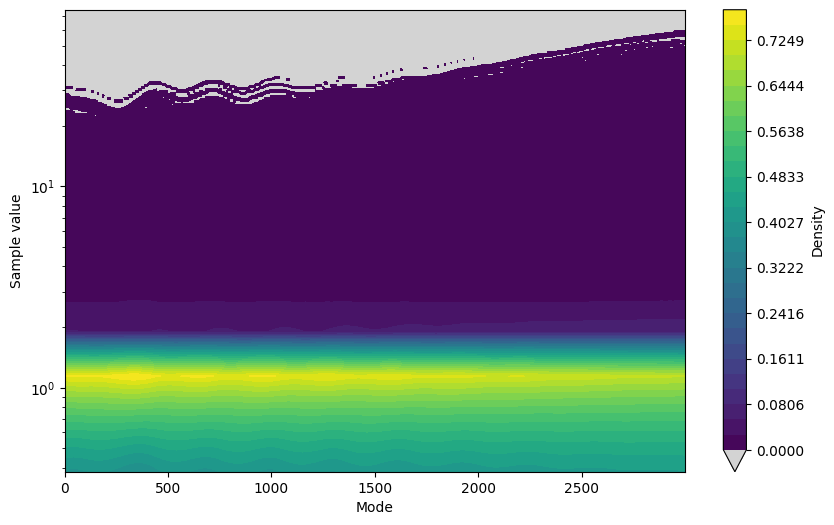

In [56]:
# Raw
plot_mode_density(data.y, logy=True)

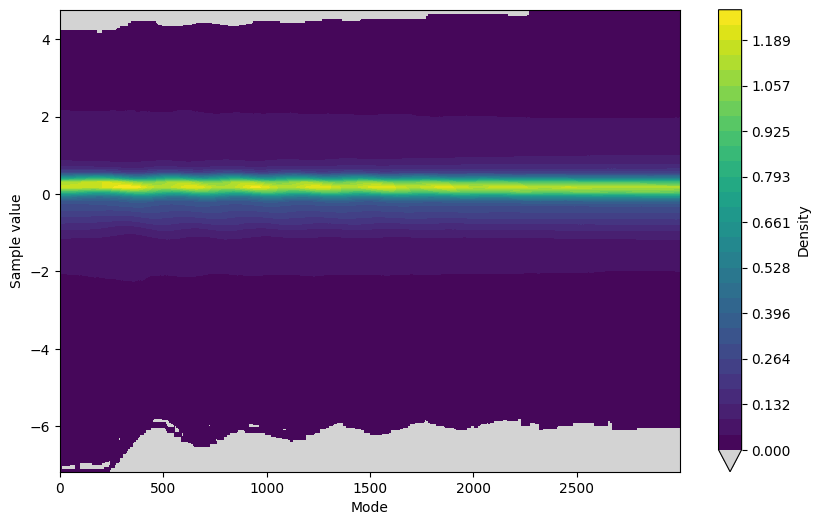

In [57]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

### cl_Tp_lensed (StandardScaler)

In [58]:
spectrum = 'cl_Tp_lensed'
spectrum_type = 'cl'

In [59]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [60]:
# Signs
print_sign(data.y)

sign +/-, min -1.00e-10, max 4.36e-09


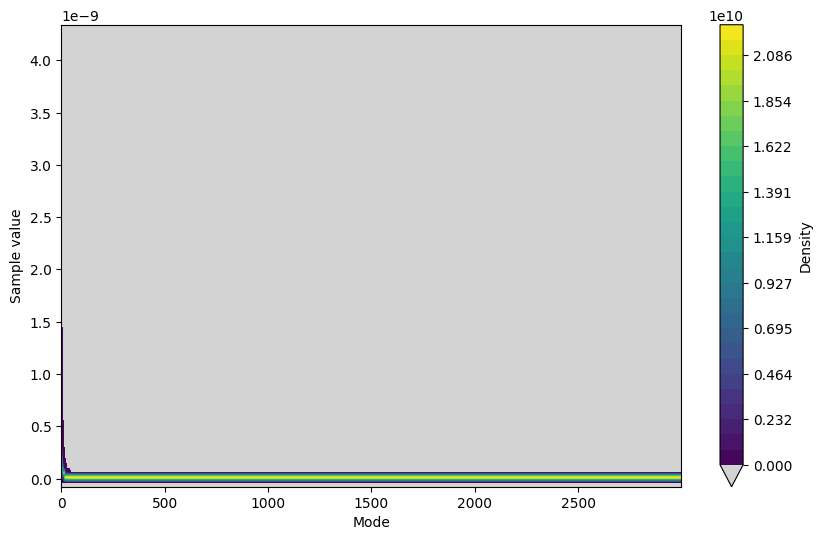

In [61]:
# Raw
plot_mode_density(data.y)

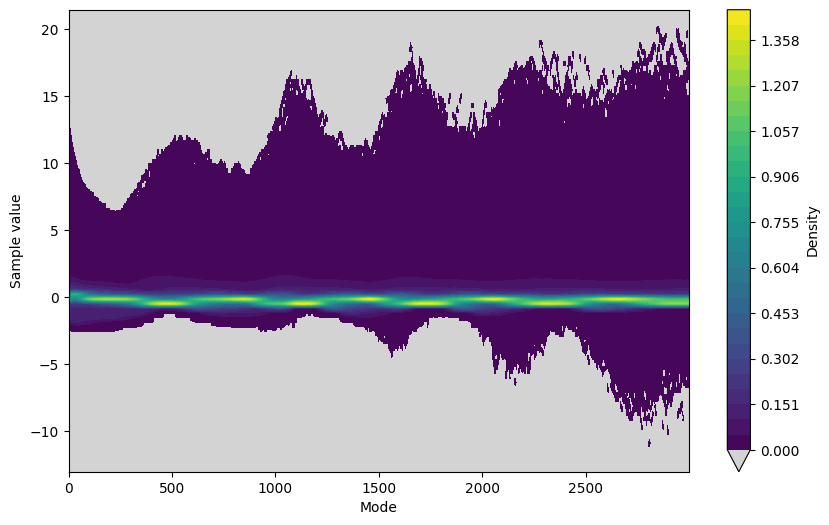

In [62]:
# StandardScaler
plot_mode_density(scale_data(data.y, 'StandardScaler'))

### cl_pp_lensed (LogStandardScaler)

In [63]:
spectrum = 'cl_pp_lensed'
spectrum_type = 'cl'

In [64]:
# Load data
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [65]:
# Signs
print_sign(data.y)

sign +  , min 9.90e-04, max 6.69e+01


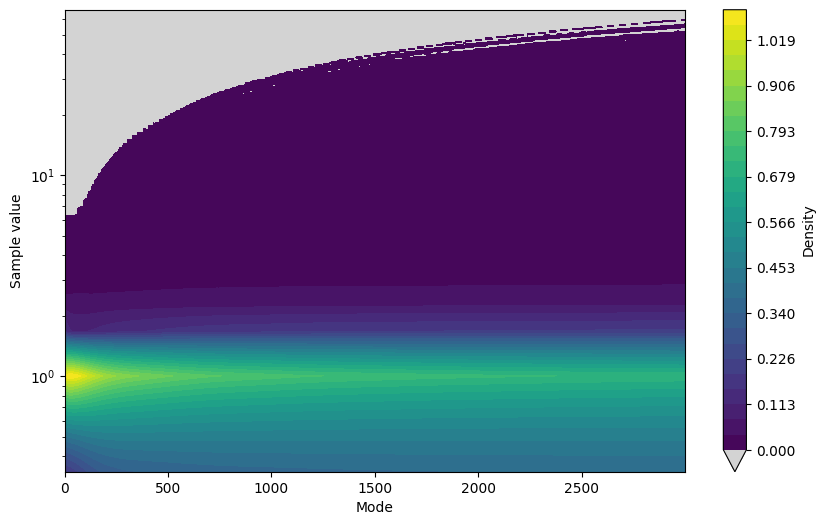

In [66]:
# Raw
plot_mode_density(data.y, logy=True)

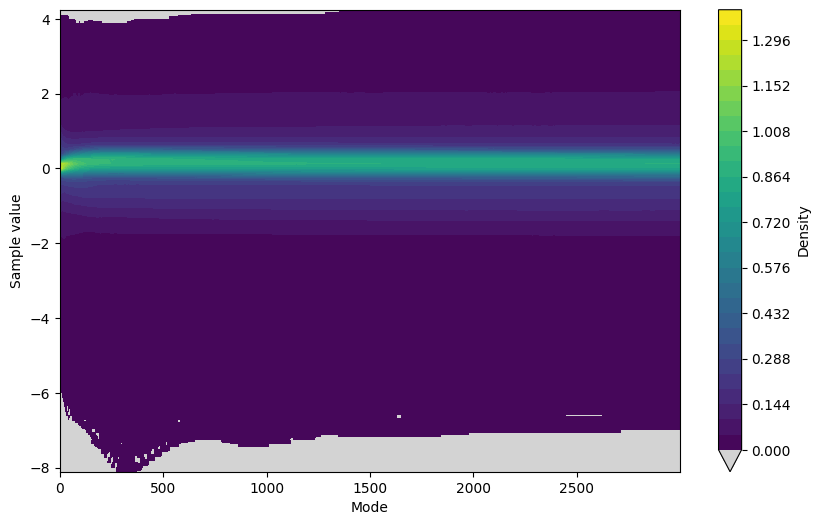

In [67]:
# LogStandardScaler
plot_mode_density(scale_data(data.y, 'LogStandardScaler'))

## Inspect

### pk_m

In [65]:
spectrum = 'pk_m'
spectrum_type = 'pk'

In [66]:
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/pk_100_ext.fits


In [67]:
# Split training and testing samples
data.train_test_split(
    0.9,
    1543,
    verbose=True)

[info] Splitting dataset in training and testing samples.
----> Fractional number of training samples: 0.9
----> Random seed for train/test split: 1543


In [68]:
print(data.y.shape)
print(data.y_train.shape)
print(data.y_test.shape)

(299997, 600)
(269997, 600)
(30000, 600)


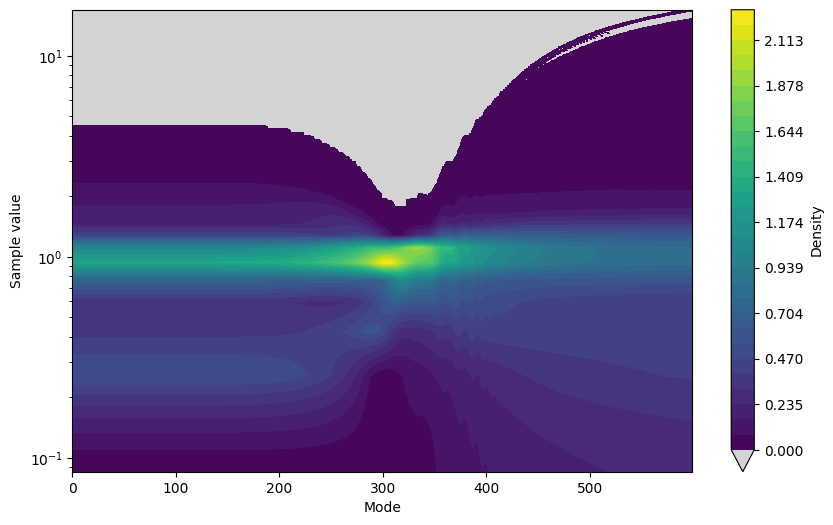

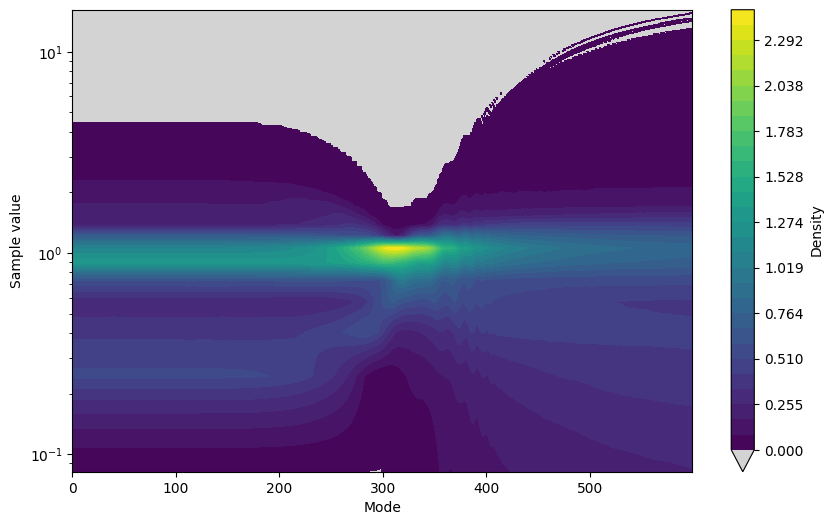

In [69]:
plot_mode_density(data.y_train, logy=True)
plot_mode_density(data.y_test, logy=True)

In [70]:
# If requested, rescale training and testing samples
data.rescale(
    'StandardScaler',
    'LogStandardScaler',
    verbose=False)


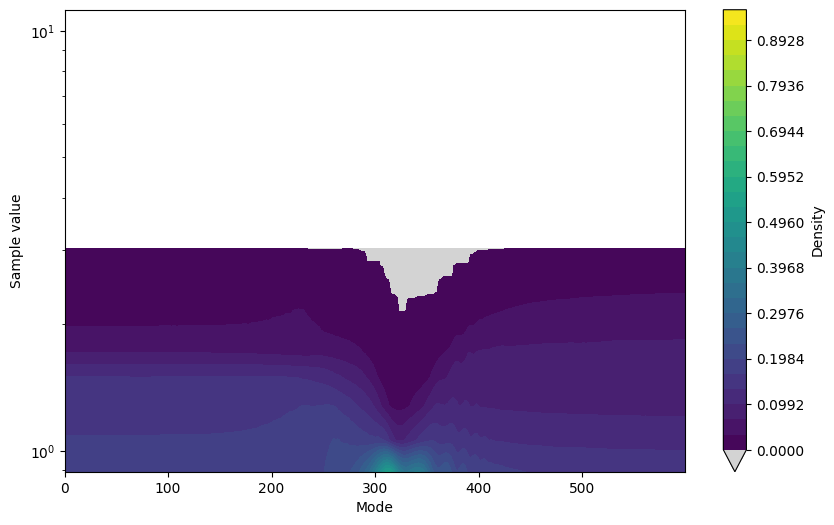

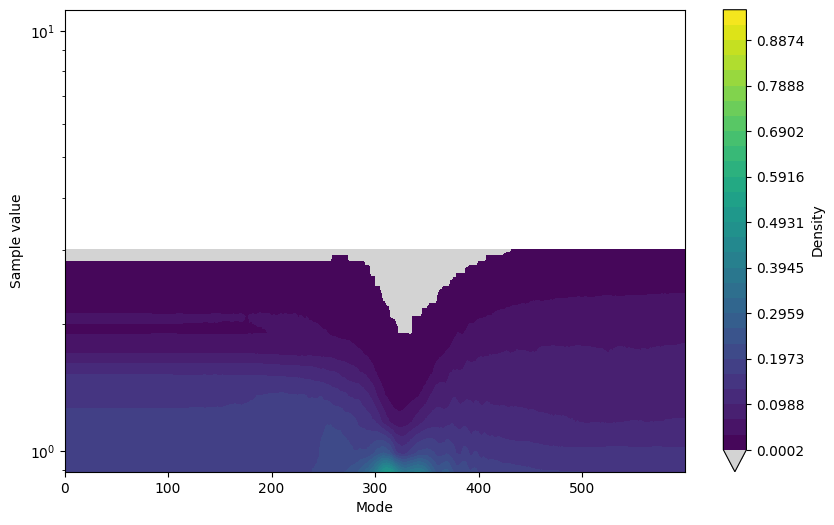

In [71]:
plot_mode_density(data.y_train, logy=True)
plot_mode_density(data.y_test, logy=True)

In [72]:
# If requested apply PCA on x and/or y
data.apply_pca(
    None,
    None,
    verbose=True)


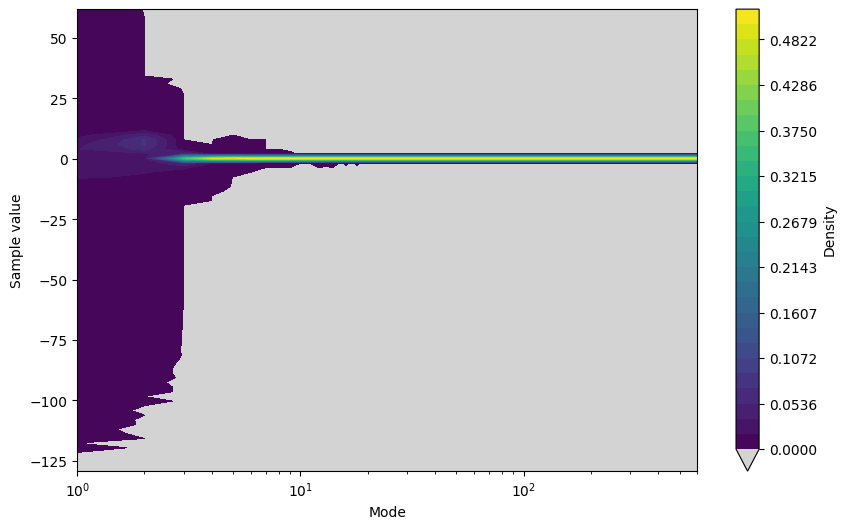

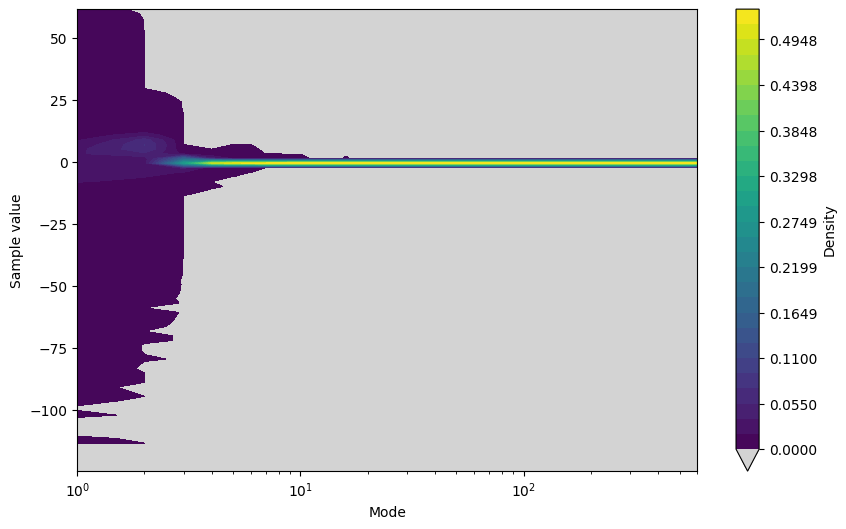

In [73]:
plot_mode_density(data.y_train, logy=False, logx=True)
plot_mode_density(data.y_test, logy=False, logx=True)

### cl_TT_lensed

In [84]:
spectrum = 'cl_TT_lensed'
spectrum_type = 'cl'

In [85]:
data = [Dataset().load(
    path=os.path.join(root, '{}/sample/{}_100_{}.fits'.format(model, spectrum_type, dr)),
    name=spectrum) for dr in data_ranges]
data = [d.remove_non_finite() for d in data]
data = Dataset.join(data, verbose=True)

[info] Joining datasets
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_std.fits
----> /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


In [86]:
# Split training and testing samples
data.train_test_split(
    0.9,
    1543,
    verbose=True)

[info] Splitting dataset in training and testing samples.
----> Fractional number of training samples: 0.9
----> Random seed for train/test split: 1543
----> Fractional number of training samples: 0.9
----> Random seed for train/test split: 1543


In [87]:
print(data.y.shape)
print(data.y_train.shape)
print(data.y_test.shape)

(299998, 2999)
(269998, 2999)
(30000, 2999)


In [88]:
y_train_before_scaling = data.y_train.copy()
y_test_before_scaling = data.y_test.copy()
print('cached raw shapes:', y_train_before_scaling.shape, y_test_before_scaling.shape)


cached raw shapes: (269998, 2999) (30000, 2999)


In [89]:
def report_log_scaler_health(matrix, label, tiny_threshold=1e-10):
    flat = matrix.reshape(-1)
    total = flat.size
    non_pos = int(np.count_nonzero(flat <= 0))
    tiny = int(np.count_nonzero((flat > 0) & (flat < tiny_threshold)))
    min_val = float(flat.min())
    min_pos = float(flat[flat > 0].min()) if non_pos < total else np.nan
    print(f"[{label}] total={total:,} non_pos={non_pos:,} (<={0}) tiny(<{tiny_threshold})={tiny:,}")
    print(f"[{label}] min raw value={min_val:.3e} | smallest positive value={min_pos:.3e}")
    mode_mins = matrix.min(axis=0)
    worst = np.argsort(mode_mins)[:5]
    print(f"[{label}] worst mode minima:")
    for idx in worst:
        name = data.y_names[idx] if data.y_names is not None else f"mode_{idx}"
        print(f"  - {name}: {mode_mins[idx]:.3e}")

report_log_scaler_health(y_train_before_scaling, 'train')
report_log_scaler_health(y_test_before_scaling, 'test')


[train] total=809,724,002 non_pos=0 (<=0) tiny(<1e-10)=0
[train] min raw value=3.181e-02 | smallest positive value=3.181e-02
[train] worst mode minima:
[train] worst mode minima:


IndexError: list index out of range

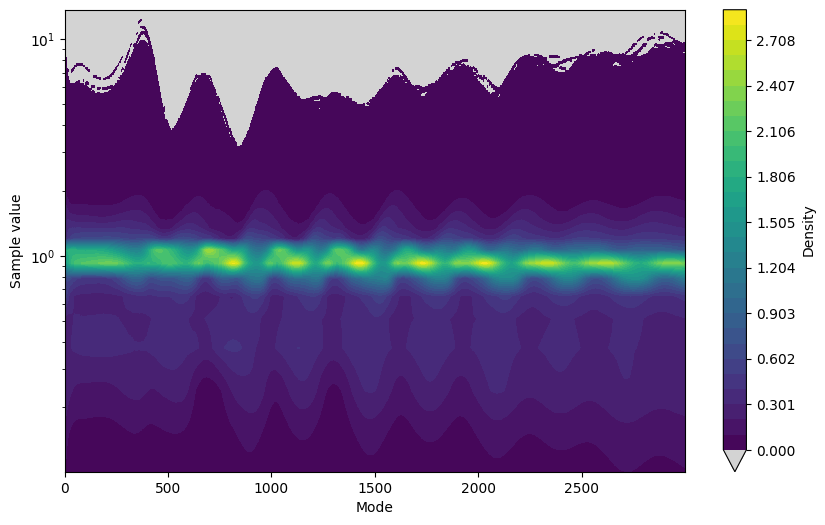

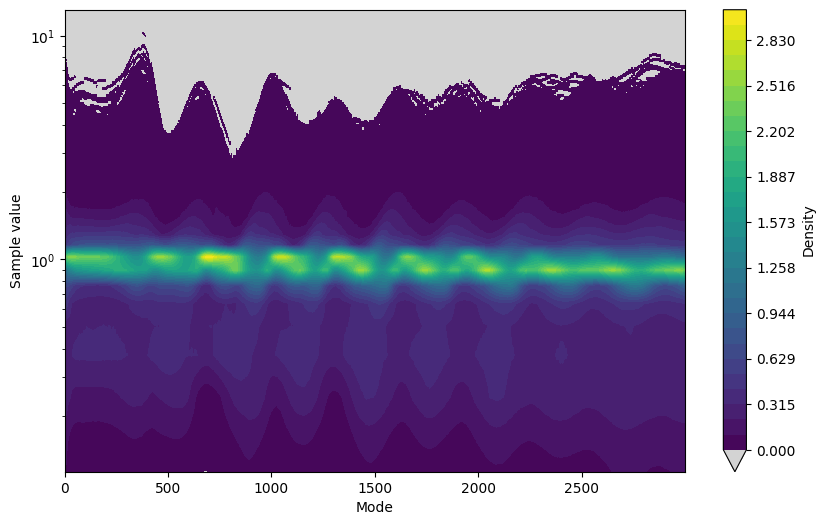

In [90]:
plot_mode_density(data.y_train, logy=True)
plot_mode_density(data.y_test, logy=True)

In [91]:
# If requested, rescale training and testing samples
data.rescale(
    'StandardScaler',
    'LogStandardScaler',
    verbose=False)


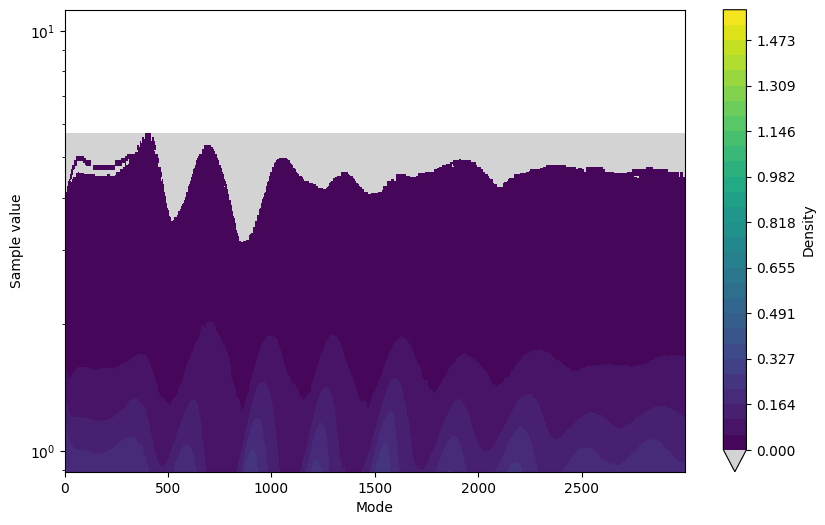

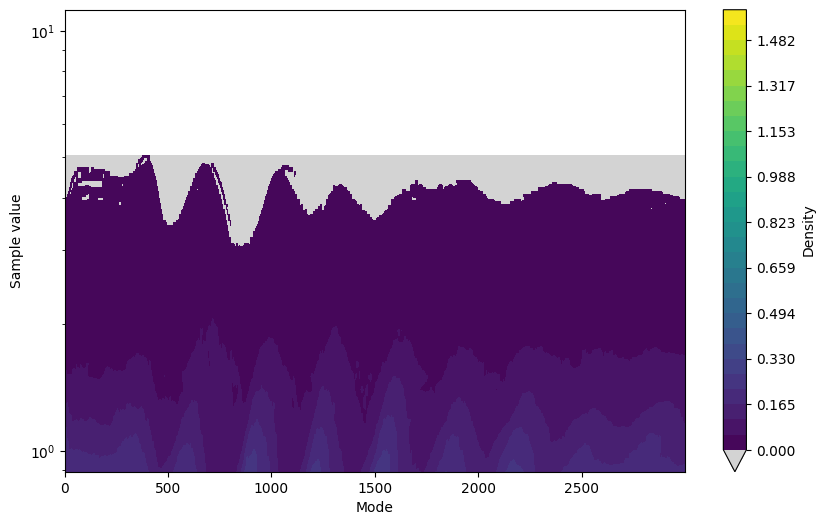

In [92]:
plot_mode_density(data.y_train, logy=True)
plot_mode_density(data.y_test, logy=True)

In [93]:
# If requested apply PCA on x and/or y
data.apply_pca(
    None,
    500,
    verbose=True)


[info] Applying PCA on y. Number of modes retained 500.


components kept: 500
  cumulative variance @ 100: 1.00000
  cumulative variance @ 200: 1.00000
  cumulative variance @ 360: 1.00000
  cumulative variance @ 500: 1.00000


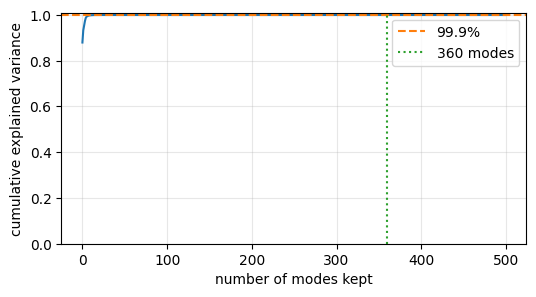

In [95]:
import matplotlib.pyplot as plt
import numpy as np

explained = data.y_pca.pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
print(f"components kept: {len(explained)}")
for n in (100, 200, 360, 500):
    if n <= len(explained):
        print(f"  cumulative variance @ {n:3d}: {cumulative[n-1]:.5f}")

plt.figure(figsize=(6, 3))
plt.plot(cumulative, lw=1.5)
plt.axhline(0.999, color='tab:orange', ls='--', label='99.9%')
plt.axvline(360, color='tab:green', ls=':', label='360 modes')
plt.xlabel('number of modes kept')
plt.ylabel('cumulative explained variance')
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [96]:
def report_pca_reconstruction(raw_values, projected_values, label):
    scaled_reference = data.y_scaler.transform(raw_values)
    reconstructed_scaled = data.y_pca.inverse_transform(projected_values)
    abs_err = np.abs(scaled_reference - reconstructed_scaled)
    rel_err = abs_err / (np.abs(scaled_reference) + 1e-12)
    mean_abs = float(np.mean(abs_err))
    median_abs = float(np.median(abs_err))
    p95_abs = float(np.quantile(abs_err, 0.95))
    mean_rel = float(np.mean(rel_err))
    median_rel = float(np.median(rel_err))
    p95_rel = float(np.quantile(rel_err, 0.95))
    print(f"[{label}] abs err: mean={mean_abs:.3e}, median={median_abs:.3e}, p95={p95_abs:.3e}")
    print(f"[{label}] rel err: mean={mean_rel:.3e}, median={median_rel:.3e}, p95={p95_rel:.3e}")

report_pca_reconstruction(y_train_before_scaling, data.y_train, 'train')
report_pca_reconstruction(y_test_before_scaling, data.y_test, 'test')


[train] abs err: mean=5.860e-10, median=3.011e-10, p95=2.055e-09
[train] rel err: mean=1.445e-08, median=8.380e-10, p95=1.347e-08
[test] abs err: mean=5.863e-10, median=3.011e-10, p95=2.054e-09
[test] rel err: mean=1.927e-08, median=8.384e-10, p95=1.348e-08
[test] abs err: mean=5.863e-10, median=3.011e-10, p95=2.054e-09
[test] rel err: mean=1.927e-08, median=8.384e-10, p95=1.348e-08


In [103]:
import pandas as pd
import numpy as np

pd.options.display.float_format = '{:0.3e}'.format

print('--- Parameter (x) split summary ---')

def summarize_split(array, names):
    rows = []
    for idx, name in enumerate(names):
        col = array[:, idx]
        rows.append({
            'parameter': name,
            'min': float(col.min()),
            'max': float(col.max()),
            'mean': float(col.mean()),
            'std': float(col.std()),
        })
    return pd.DataFrame(rows).set_index('parameter')

def mode_name(names, idx):
    if names is not None and idx < len(names):
        return names[idx]
    return f'mode_{idx}'

def maybe_inverse(values, scaler):
    if scaler is None:
        return values
    return scaler.inverse_transform(values)

def report_parameter_block(label, train_vals, test_vals, names):
    print(f'\n[{label}]')
    train_stats = summarize_split(train_vals, names)
    test_stats = summarize_split(test_vals, names)
    comparison = pd.concat({'train': train_stats, 'val': test_stats}, axis=1)
    print(comparison)
    return train_stats, test_stats

x_scaler = getattr(data, 'x_scaler', None)
x_train_scaled, x_test_scaled = data.x_train, data.x_test
x_train_raw = maybe_inverse(x_train_scaled, x_scaler)
x_test_raw = maybe_inverse(x_test_scaled, x_scaler)

scaled_train_stats, scaled_test_stats = report_parameter_block('scaled parameter space', x_train_scaled, x_test_scaled, data.x_names)
raw_train_stats, raw_test_stats = report_parameter_block('physical parameter space', x_train_raw, x_test_raw, data.x_names)

train_range = raw_train_stats[['min', 'max']]
val_outside = []
for name in data.x_names:
    if (raw_test_stats.at[name, 'min'] < train_range.at[name, 'min'] or
            raw_test_stats.at[name, 'max'] > train_range.at[name, 'max']):
        val_outside.append(name)
print('\nValidation parameters outside train range (physical space):', val_outside or 'None detected')

print('\n--- Spectra (y) split summary ---')
y_train_means = y_train_before_scaling.mean(axis=0)
y_test_means = y_test_before_scaling.mean(axis=0)
y_train_stds = y_train_before_scaling.std(axis=0)
y_test_stds = y_test_before_scaling.std(axis=0)
mean_diff = np.abs(y_train_means - y_test_means)
std_diff = np.abs(y_train_stds - y_test_stds)

print('Top |Δ mean| modes (regardless of index):')
worst = np.argsort(mean_diff)[-5:][::-1]
for idx in worst:
    name = mode_name(data.y_names, idx)
    print(f"{name}: mean train={y_train_means[idx]:.3e}, val={y_test_means[idx]:.3e}, |Δ|={mean_diff[idx]:.3e}")

print('\nTop |Δ std| modes:')
worst_std = np.argsort(std_diff)[-5:][::-1]
for idx in worst_std:
    name = mode_name(data.y_names, idx)
    print(f"{name}: std train={y_train_stds[idx]:.3e}, val={y_test_stds[idx]:.3e}, |Δ|={std_diff[idx]:.3e}")

first_modes = min(5, y_train_means.shape[0])
print(f"\nFirst {first_modes} PCA modes (ordered by index):")
for idx in range(first_modes):
    name = mode_name(data.y_names, idx)
    print(
        f"{name}: mean train={y_train_means[idx]:.3e}, val={y_test_means[idx]:.3e}, |Δ|={mean_diff[idx]:.3e}; "
        f"std train={y_train_stds[idx]:.3e}, val={y_test_stds[idx]:.3e}, |Δ|={std_diff[idx]:.3e}"
    )


--- Parameter (x) split summary ---

[scaled parameter space]
                 train                                       val            \
                   min       max       mean       std        min       max   
parameter                                                                    
h           -2.576e+00 6.254e+00 -4.211e-18 1.460e+00 -2.283e+00 5.876e+00   
Omega_m     -5.131e+00 4.602e+00  5.948e-18 1.004e+00 -4.471e+00 4.458e+00   
Omega_b     -4.158e+00 4.360e+00  1.663e-17 9.964e-01 -4.132e+00 4.312e+00   
ln_A_s_1e10 -4.918e+00 4.760e+00 -6.369e-18 9.921e-01 -4.639e+00 4.707e+00   
n_s         -4.396e+00 4.124e+00 -1.579e-17 9.717e-01 -4.322e+00 4.077e+00   
tau_reio    -3.816e+00 3.687e+00 -3.200e-17 8.654e-01 -3.649e+00 3.656e+00   
N_ur        -3.915e+00 3.787e+00  8.237e-18 8.221e-01 -3.655e+00 3.471e+00   
m_ncdm      -3.082e+00 3.270e+00 -2.142e-17 7.180e-01 -3.025e+00 3.132e+00   

                                  
                  mean       std  
parameter

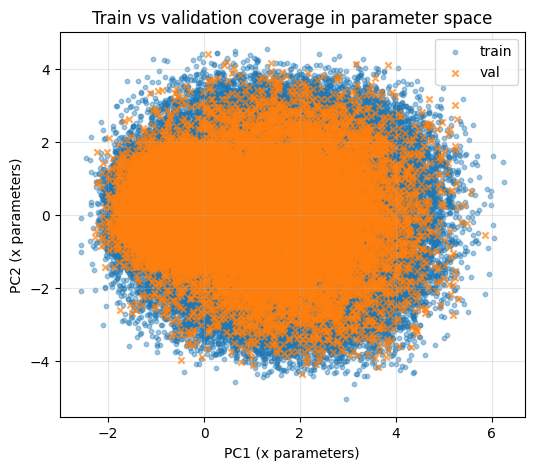

In [101]:
from sklearn.decomposition import PCA as SkPCA

combined = np.vstack([data.x_train, data.x_test])
reducer = SkPCA(n_components=2, random_state=0)
proj = reducer.fit_transform(combined)
n_train = data.x_train.shape[0]
proj_train = proj[:n_train]
proj_val = proj[n_train:]

plt.figure(figsize=(6, 5))
plt.scatter(proj_train[:, 0], proj_train[:, 1], s=10, alpha=0.4, label='train')
plt.scatter(proj_val[:, 0], proj_val[:, 1], s=20, alpha=0.7, label='val', marker='x')
plt.xlabel('PC1 (x parameters)')
plt.ylabel('PC2 (x parameters)')
plt.legend()
plt.title('Train vs validation coverage in parameter space')
plt.grid(alpha=0.3)
plt.show()


In [82]:
print(data.y.shape)
print(data.y_train.shape)
print(data.y_test.shape)

(299998, 2999)
(269998, 500)
(30000, 500)


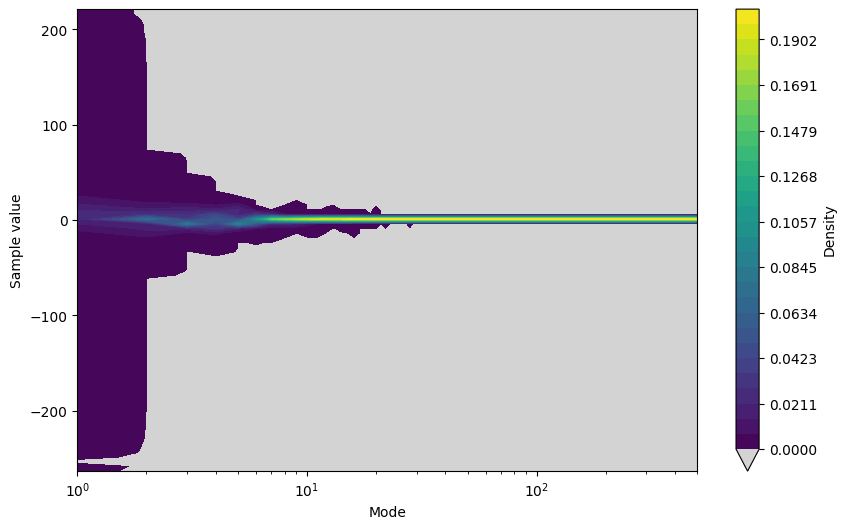

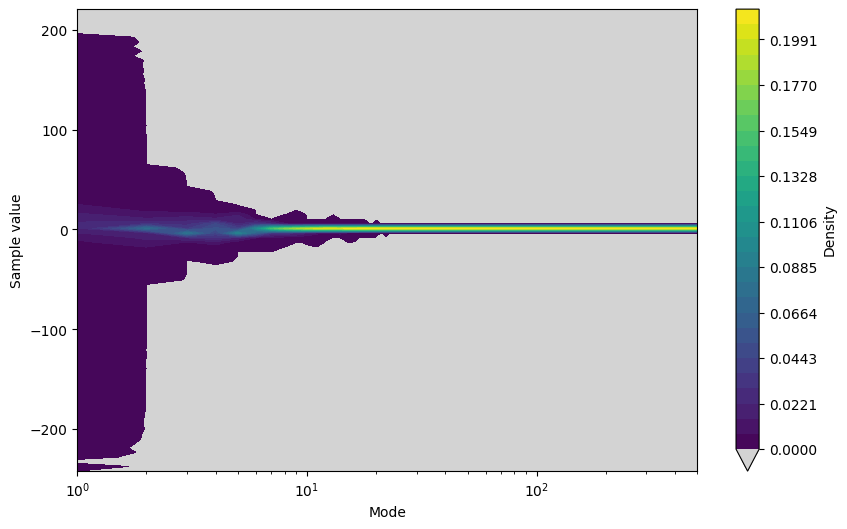

In [83]:
plot_mode_density(data.y_train, logy=False, logx=True)
plot_mode_density(data.y_test, logy=False, logx=True)